<a href="https://colab.research.google.com/github/RyanW1610/TMS-Shipment-Delay-Prediction/blob/main/Wilson_Ryan_TMS_Shipment_Delay_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Transportation Management System (TMS) Shipment Delay Prediction

**Author:** Ryan Wilson

**Dataset Source:** Kaggle - E-Commerce Shipping Data

## Project Overview

This project uses machine learning to predict shipment delays using transportation management data. I cleaned and prepared the data, explored it to better understand the information, trained different machine learning models, and compared the results to see which model performed the best.

## 1. Dataset Acquisition

The dataset was obtained from Kaggle using KaggleHub. It contains historical e-commerce shipment information that will be used to build machine learning models for predicting shipment delivery performance.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prachi13/customer-analytics")

print("Path to dataset files:", path)

100%|██████████| 121k/121k [00:00<00:00, 55.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/prachi13/customer-analytics/versions/1


In [ ]:
import os

files = os.listdir(path)
print(files)

['Train.csv']


## 2. Load the Dataset

The downloaded dataset was loaded into a Pandas DataFrame to prepapre it for data exploration, preprocessing, and machine leaning model development.

In [ ]:
import pandas as pd
import os

# Load the sataset
df = pd.read_csv(os.path.join(path, "Train.csv"))

# Display the first five rows
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


## 3. Dataset Overview

The dataset was examined to understand its size, features, data types, and quality before performing exploratory data analysis and preprocessing. Understanding the structure of the dataset helps identify missing values,categorical variables, and numerical variables that will be used during model development.

In [ ]:
# Display the number of rows and columns
print ("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (10999, 12)

Column Names:
Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

Data Types:
ID                      int64
Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object


In [ ]:
# Display datset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [ ]:
# Check for mising values
df.isnull().sum()

,0
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


In [ ]:
# Summary statistics for numerical features
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was performed to better understand the dataset before building the machine learning models. The analysis examined the distribution of the variables, identified patterns and trends within the data, and explored relationships between the predictor variables and the target variable. These insights helped guide the preprocessing steps and supported the selection of appropriate machine learning models for shipment delay prediction.

In [ ]:
# Target variable distribution
df["Reached.on.Time_Y.N"]. value_counts()

,count
Reached.on.Time_Y.N,
1,6563
0,4436


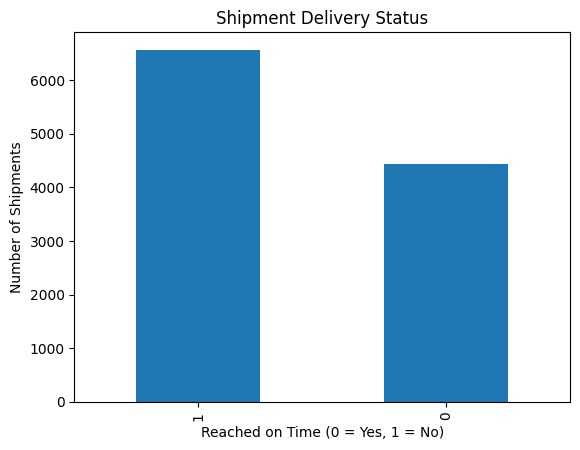

In [ ]:
import matplotlib.pyplot as plt

df["Reached.on.Time_Y.N"].value_counts().plot(kind="bar")

plt.title("Shipment Delivery Status")
plt.xlabel("Reached on Time (0 = Yes, 1 = No)")
plt.ylabel("Number of Shipments")
plt.show()

In [ ]:
# Shipment method distribution
df["Mode_of_Shipment"].value_counts()

,count
Mode_of_Shipment,
Ship,7462
Flight,1777
Road,1760


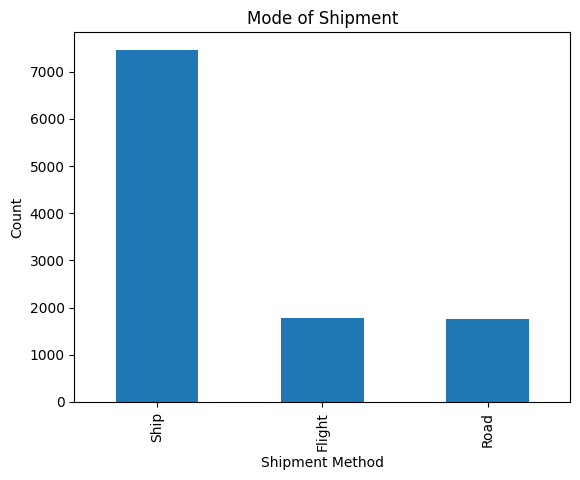

In [ ]:
df["Mode_of_Shipment"].value_counts().plot(kind="bar")

plt.title("Mode of Shipment")
plt.xlabel("Shipment Method")
plt.ylabel("Count")
plt.show()


In [ ]:
# Product importance
df["Product_importance"].value_counts()

,count
Product_importance,
low,5297
medium,4754
high,948


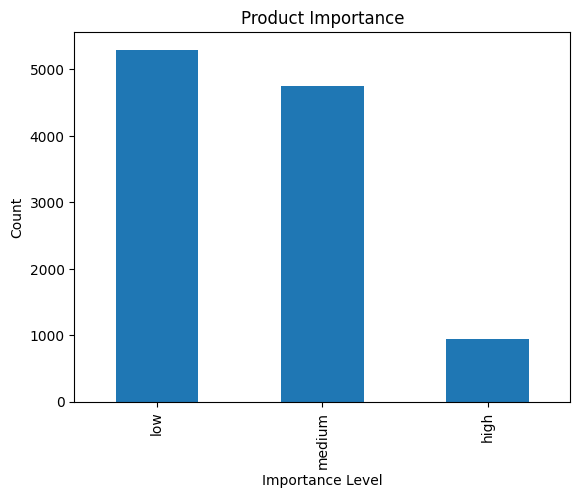

In [ ]:
df["Product_importance"].value_counts().plot(kind="bar")

plt.title("Product Importance")
plt.xlabel("Importance Level")
plt.ylabel("Count")
plt.show()

## 5. Data Preprocessing

The dataset was prepared for machine learning by converting categorical variables into numerical values. Since machine learnig algorithms require numerical inputs, label encoding was applied to the categorical features while preserving the numerical variables. The dataset was then separated into predictor variables (X) and the target variable (y) for model development.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
label_encoder = LabelEncoder()

#Encode categorical columns
categorical_columns = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Gender"]
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

    df.head()

In [ ]:
# Features and target
X = df.drop("Reached.on.Time_Y.N", axis=1)
y = df["Reached.on.Time_Y.N"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (10999, 11)
Target: (10999,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (8799, 11)
Testing set: (2200, 11)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


## 6. Model Selection, Training, and Hyperparameter Search

Three machine learning models were selected for shipment delay predicition: Logistics Regression, Decision Tree, and Random Forest. These models were chosen to compare a linear classification method with two three-based claassification methods.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model using the scaled training data
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression training completed.")


Logistic Regression training completed.


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(n_estimators= 100, random_state=42)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


## 7. Evauluation, Results, and Analysis

The trained machine learning models were evaluated using the testing dataset. Performance was compared using Accuracy, Precision, Recall, and F1-score to determine which model provided the best shipment delay prediction.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression predictions
lr_predictions = logistic_model.predict(X_test_scaled)

print("Predictions generated for Logistic Regression.")

Predictions generated for Logistic Regression.


In [ ]:
# Decision Tree prediciotns
dt_predictions = decision_tree_model.predict(X_test)

print("Predictions generated for Decision Tree.")

Predictions generated for Decision Tree.


In [ ]:
# Random Forest predictions
rf_predictions = random_forest_model.predict(X_test)

print("Predictions generated for Random Forest.")

Predictions generated for Random Forest.


In [ ]:
import pandas as pd

# Compare model performance
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, lr_predictions), accuracy_score(y_test, dt_predictions), accuracy_score(y_test, rf_predictions)],

    "Precision": [precision_score(y_test, lr_predictions), precision_score(y_test, dt_predictions), precision_score(y_test, rf_predictions)],

    "Recall": [recall_score(y_test, lr_predictions), recall_score(y_test, dt_predictions), recall_score(y_test, rf_predictions)],

    "F1-Score": [f1_score(y_test, lr_predictions), f1_score(y_test, dt_predictions), f1_score(y_test, rf_predictions)],
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.652727,0.714173,0.691188,0.702492
1,Decision Tree,0.651818,0.698600,0.726437,0.712246
2,Random Forest,0.682727,0.797841,0.622989,0.699656


### Hyperparameter Tuning

GridSearchCV was used to test different combinations of settings for the Random Forest Model. This process helps identify the combination of hyperparameters that produces the best performance on the training data.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter options for Random Forest
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

# Create the GridSearchCV model
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Run the hyperparameter search
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1-Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Best Cross-Validation F1-Score: 0.6841179344954477
